In [25]:
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)


import importlib
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.monitor import load_results
from stable_baselines3 import DQN
# from stable_baseline import DQN
import matplotlib.pyplot as plt
from itertools import product
import torch
import numpy as np

# Import as module
import environment.users.citation_users_loader as citation_users_loader
importlib.reload(citation_users_loader)

import environment.citations.citation_selector as citation_selector
importlib.reload(citation_selector)

import environment.citation_reward_shaping as citation_reward_shaping
importlib.reload(citation_reward_shaping)

import environment.citations.citation as citation
importlib.reload(citation)

import environment.users.citation_user as citation_user
importlib.reload(citation_user)

import environment.citations.citation_loader as citation_loader
importlib.reload(citation_loader)

import environment.citation_memory as citation_memory
importlib.reload(citation_memory)

import environment.users.user_rater as user_rater
importlib.reload(user_rater)

import environment.user_env as user_env
importlib.reload(user_env)

from environment.user_env import UserEnv
from environment.users.citation_users_loader import CitationUsersLoader
from environment.citations.citation_loader import CitationsLoader
from environment.citations.citation import Citation
from environment.citations.citation_selector import CitationsSelector
from environment.citation_memory import CitationMemory, UserPaperInteraction
from environment.users.citation_user import CitationUser
from environment.users.user_rater import RuleBasedCitationRater
from environment.citation_reward_shaping import CitationRewardReshapingExpDecay

In [2]:
users_loader = CitationUsersLoader("../environment/users/datasets/users_relevance_threshold.json")
user_list = users_loader.get_users()
paper_loader = CitationsLoader("../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv")
selector = CitationsSelector()
rater = RuleBasedCitationRater()
reward_shaping = CitationRewardReshapingExpDecay()

## Randomly

In [66]:
from wandb.integration.sb3 import WandbCallback
import wandb

In [6]:
env = UserEnv(
        render_mode= "human",
        debug=True,
        debug_path=f"debug_log/user_env_DQN_all_users_random.log",
        items_loader=paper_loader,
        user_list=user_list,
        items_selector=selector,
        reward_shaping=reward_shaping,
        max_interactions=200,
        render_path="./tmp/render/",
    )
env = Monitor(env, filename=f"monitor_DQN_alluser_random.csv", info_keywords=("user_id", "item_interact", "item_clicks"))
model = DQN("MultiInputPolicy", env, verbose=1, 
                device="cpu",
                buffer_size=20000,
                target_update_interval=2000,
                exploration_fraction=0.5,
                learning_starts=1000,
                batch_size=288,
                exploration_final_eps=0.1)
model.learn(total_timesteps=150000, progress_bar=True)

In [12]:
model.save("models/random_dqn_citation_recommender")

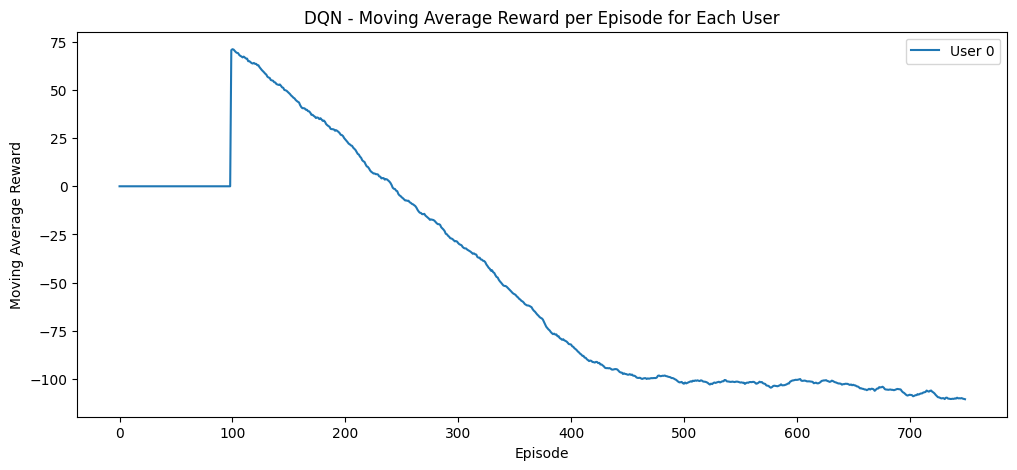

In [11]:
def plot_rewards(all_user_rewards, window_size=100):
    """
    all_user_rewards: list of lists/arrays, each one is the rewards for one user
    window_size: smoothing window for moving average
    """
    plt.figure(figsize=(12, 5))
    plt.xlabel('Episode')
    plt.ylabel('Moving Average Reward')
    plt.title(f"DQN - Moving Average Reward per Episode for Each User")

    for i, rewards in enumerate(all_user_rewards):
        rewards_t = torch.tensor(rewards, dtype=torch.float)

        # raw rewards (optional)
        # plt.plot(rewards_t.numpy(), alpha=0.2, label=f'run {i} raw')

        # smoothed (moving average)
        if len(rewards_t) >= window_size:
            means = rewards_t.unfold(0, window_size, 1).mean(1).view(-1)
            # pad the beginning so lengths match
            pad = torch.zeros(window_size - 1)
            smoothed = torch.cat((pad, means))
            plt.plot(smoothed.numpy(), label=f'User {i}')
        else:
            # too short to smooth, just plot raw
            plt.plot(rewards_t.numpy(), label=f'User {i}')

    plt.legend()

    plt.savefig(
        "export_images/DQN Moving Average Reward.png",
        dpi=300,               # resolution in dots per inch
        bbox_inches="tight"    # trim extra whitespace
    )

    plt.show()

plot_rewards([env.get_episode_rewards()])

In [27]:
user_rewards = {}
param_rewards = {}
params_monitor = {}
timesteps = 150000

hyperparameter = {
    "exploration_fraction": [0.8, 0.9],
    "learning_starts": [5000, 10000],
    "batch_size": [64, 128],
    "exploration_final_eps": [0.1, 0.2],
}

param_names = list(hyperparameter.keys())
env = UserEnv(
        render_mode= "human",
        # debug=True,
        # debug_path=f"debug_log/user_env_DQN_all_users_{timesteps}.log",
        items_loader=paper_loader,
        user_list=user_list,
        items_selector=selector,
        reward_shaping=reward_shaping,
        render_path="./tmp/render/",
    )

i = 0
for args in product(*hyperparameter.values()):
    i += 1
    params = dict(zip(param_names, args))
    key = tuple(args)
    env = Monitor(env, filename=f"monitor_DQN_alluser_param{i}.csv", info_keywords=("user_id", "item_interact", "item_clicks"))
    
    params_monitor[key] = env

    print(f"Params: {params}")

    model = DQN("MultiInputPolicy", env, verbose=1, 
                device="cpu",
                buffer_size=20000,
                target_update_interval=500,
                **params)
                
    model.learn(total_timesteps=timesteps)
    param_rewards[key] = env.get_episode_rewards()
    # user_rewards[key][user.id].append(env.get_episode_rewards())

# best_params = max(model_rewards, key=lambda p: sum(model_rewards[p]))
# user_best_param[user.id] = best_params
# user_rewards[user.id][best_params] = model_rewards[best_params]

In [ ]:
mean_by_param = {}
for params, per_user_rewards in user_rewards.items():
    # per_user_rewards is a dict user_id → list of that user’s episode rewards
    user_means = [sum(rews) / len(rews) for rews in per_user_rewards.values()]
    mean_by_param[params] = sum(user_means) / len(user_means)

# 2) Find the params with the highest overall mean
best_params = max(mean_by_param, key=mean_by_param.get)
best_score  = mean_by_param[best_params]

print(f"Best params: {best_params}, avg reward = {best_score:.3f}")

In [ ]:
best_model = DQN("MultiInputPolicy", env, device="cpu",
                    buffer_size=20000,
                    target_update_interval=500,
                    **best_params)
best_model.save("models/dqn_citation_recommender")

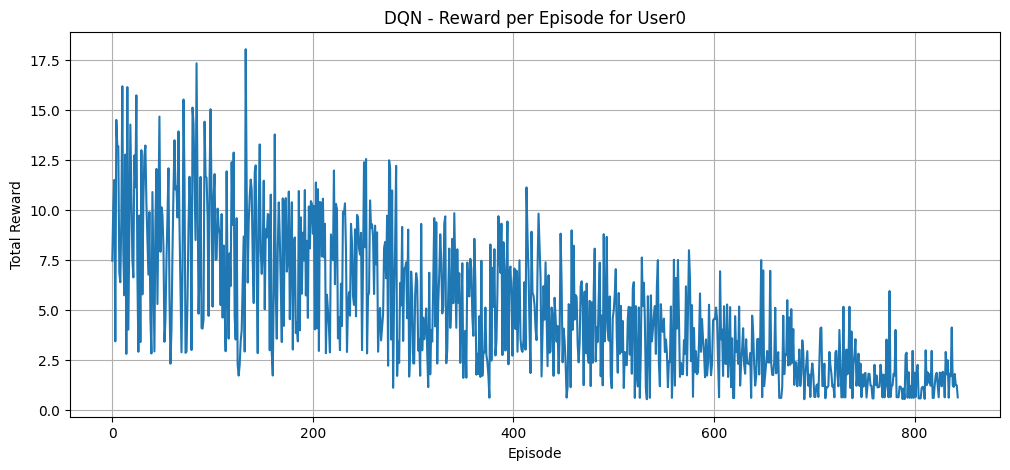

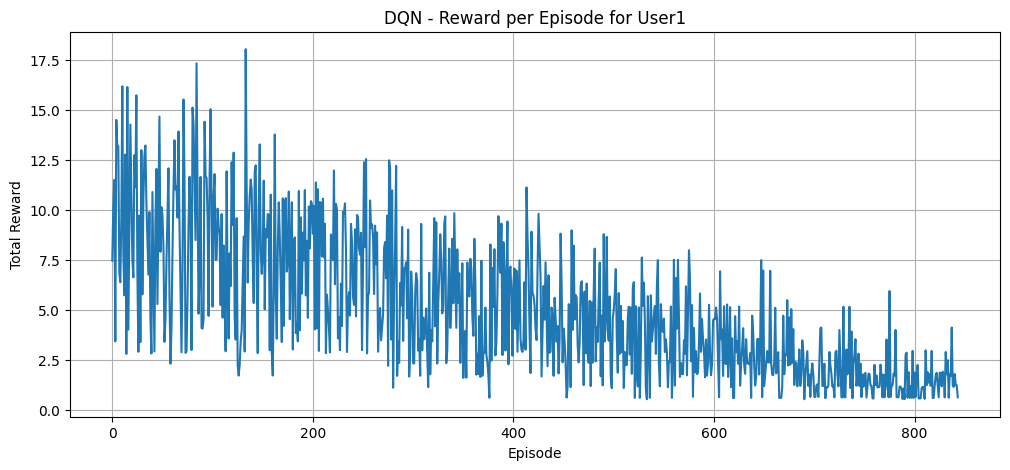

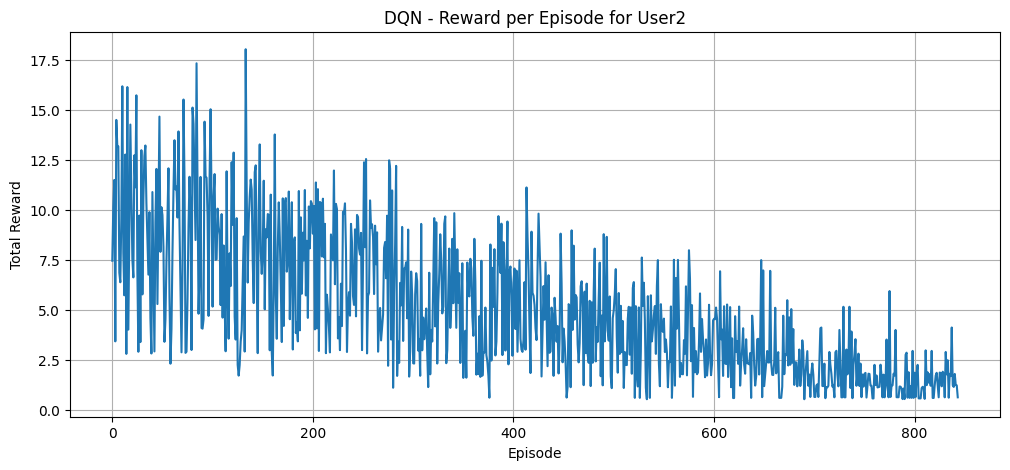

In [30]:
i = 0

for rewards in user_rewards:
    rewards = env.get_episode_rewards()
    plt.figure(figsize=(12, 5))
    plt.plot(rewards)
    plt.title(f"DQN - Reward per Episode for User{i}")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.grid(True)
    plt.show()

    i += 1

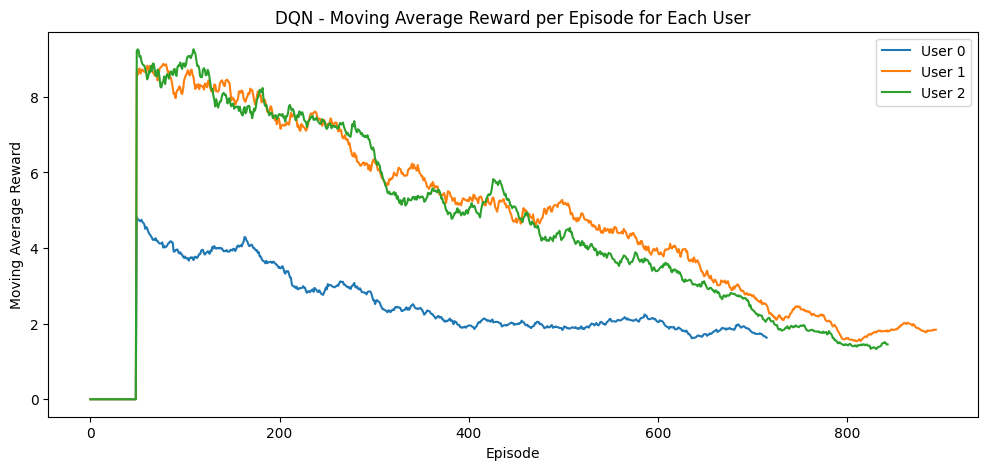

In [60]:
def plot_rewards(all_user_rewards, window_size=50):
    """
    all_user_rewards: list of lists/arrays, each one is the rewards for one user
    window_size: smoothing window for moving average
    """
    plt.figure(figsize=(12, 5))
    plt.xlabel('Episode')
    plt.ylabel('Moving Average Reward')
    plt.title(f"DQN - Moving Average Reward per Episode for Each User")

    for i, rewards in enumerate(all_user_rewards):
        rewards_t = torch.tensor(rewards, dtype=torch.float)

        # raw rewards (optional)
        # plt.plot(rewards_t.numpy(), alpha=0.2, label=f'run {i} raw')

        # smoothed (moving average)
        if len(rewards_t) >= window_size:
            means = rewards_t.unfold(0, window_size, 1).mean(1).view(-1)
            # pad the beginning so lengths match
            pad = torch.zeros(window_size - 1)
            smoothed = torch.cat((pad, means))
            plt.plot(smoothed.numpy(), label=f'User {i}')
        else:
            # too short to smooth, just plot raw
            plt.plot(rewards_t.numpy(), label=f'User {i}')

    plt.legend()

    plt.savefig(
        "export_images/DQN Moving Average Reward.png",
        dpi=300,               # resolution in dots per inch
        bbox_inches="tight"    # trim extra whitespace
    )

    plt.show()

plot_rewards(user_rewards)

In [43]:
import pandas as pd
import re
import ast

In [235]:
def to_int_tuple(s: str):
    # 1) replace np.int64(123) with just 123
    cleaned = re.sub(r'np\.int64\(\s*(\d+)\s*\)', r'\1', s)
    # 2) literal_eval the result to get a Python tuple of ints
    return ast.literal_eval(cleaned)

# apply it to your DataFrame
df = pd.read_csv("monitor_DQN_alluser_random.csv.monitor.csv", skiprows=1)
df['item_interact_tuple'] = df['item_interact'].apply(ast.literal_eval)
df['item_clicks_tuple'] = df['item_clicks'].apply(ast.literal_eval)

In [236]:
df['item_interact_tuple'].explode().reset_index()['item_interact_tuple'].nunique()

24151

In [237]:
interacted_papers_id = df['item_interact_tuple'].explode().reset_index()['item_interact_tuple'].unique()
interacted_papers = paper_loader.load_items_from_ids(interacted_papers_id)
recommended_papers = {
    "id": [],
    "title": [],
    "publication_year": [],
    "quartile_year": [],
    "cited_by_count": [],
    "quartile_cite": [],
    "topics": [],
    # "clicked": []
}

for i in range(len(interacted_papers)):
    recommended_papers["id"].append(interacted_papers[i].id)
    recommended_papers["title"].append(interacted_papers[i].title)
    recommended_papers["publication_year"].append(interacted_papers[i].year)
    recommended_papers["quartile_year"].append(interacted_papers[i].quartile_year)
    recommended_papers["cited_by_count"].append(interacted_papers[i].cited_by_count)
    recommended_papers["quartile_cite"].append(interacted_papers[i].quartile_cite)
    recommended_papers["topics"].append(interacted_papers[i].topics)
    # recommended_papers["clicked"].append(df['item_clicks_tuple'][i])

recommended_papers_df = pd.DataFrame(recommended_papers)
recommended_papers_df

,id,title,publication_year,quartile_year,cited_by_count,quartile_cite,topics
0,177,Geographical proximity and scientific collabor...,1994,0.168350,468,0.990481,"[scientometrics and bibliometrics research, In..."
1,34669,Communicating science to the public Workshop &...,2014,0.515152,0,0.000000,"[scientometrics and bibliometrics research, Ac..."
2,37829,Predicting Suspected Predatory Open Access Com...,2023,0.914141,0,0.000000,"[scientometrics and bibliometrics research, Ac..."
3,7060,Nature and characteristics of global attention...,2023,0.914141,6,0.712121,"[scientometrics and bibliometrics research, In..."
4,44491,"""Innovative or efficient? Actually I need both.""",2010,0.333333,0,0.000000,"[scientometrics and bibliometrics research, Ac..."
...,...,...,...,...,...,...,...
24146,34217,LibGuides: Faculty Scholarship and Research Su...,2014,0.515152,0,0.000000,"[scientometrics and bibliometrics research, Pu..."
24147,36087,Cross-Team Collaboration and Diversity in the ...,2023,0.914141,0,0.000000,"[scientometrics and bibliometrics research, Me..."
24148,12467,"New economics of science, economics of scienti...",2012,0.414141,9,0.767677,"[scientometrics and bibliometrics research, Sc..."
24149,27854,Sydney Rowland (1872–1917) World’s first edito...,2018,0.737374,1,0.500000,"[scientometrics and bibliometrics research, Hi..."


## Diversity

In [238]:
from sklearn.decomposition import PCA
import numpy as np
from sentence_transformers import SentenceTransformer

In [239]:
dataset = pd.read_csv("../environment/citations/datasets/cleaned-scientometrics-and-bibliometrics-research.csv")
sampled_dataset = dataset.sample(
    n=recommended_papers_df.shape[0],
    replace=True,                      # allow repeats
    weights='cited_by_count',          # use this column as relative weights
    random_state=42
)

### Topics

In [240]:
bert_model = SentenceTransformer("all-MiniLM-L6-v2")
all_embeddings = []
for topics in recommended_papers_df['topics']:
    # get each topic’s 384‑d vector
    vecs = bert_model.encode(topics, convert_to_tensor=False)
    avg = np.mean(vecs, axis=0)
    all_embeddings.append(avg)

embeddings = np.vstack(all_embeddings)

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

recommended_papers_df['x'] = coords[:, 0]
recommended_papers_df['y'] = coords[:, 1]

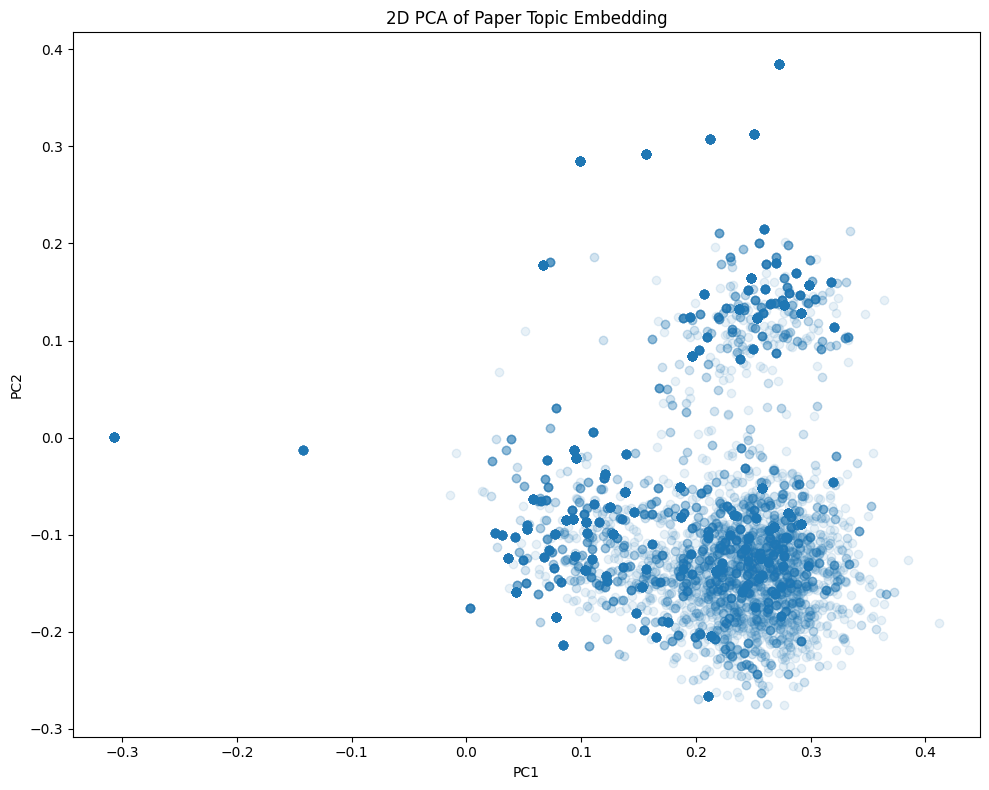

In [243]:
plt.figure(figsize=(10, 8))
plt.scatter(recommended_papers_df['x'], recommended_papers_df['y'], alpha=0.1)
plt.title("2D PCA of Paper Topic Embedding")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()

plt.savefig(
    "export_images/DQN Topic Clustering",
    dpi=300,               # resolution in dots per inch
    bbox_inches="tight"    # trim extra whitespace
)

plt.show()

### Novelty

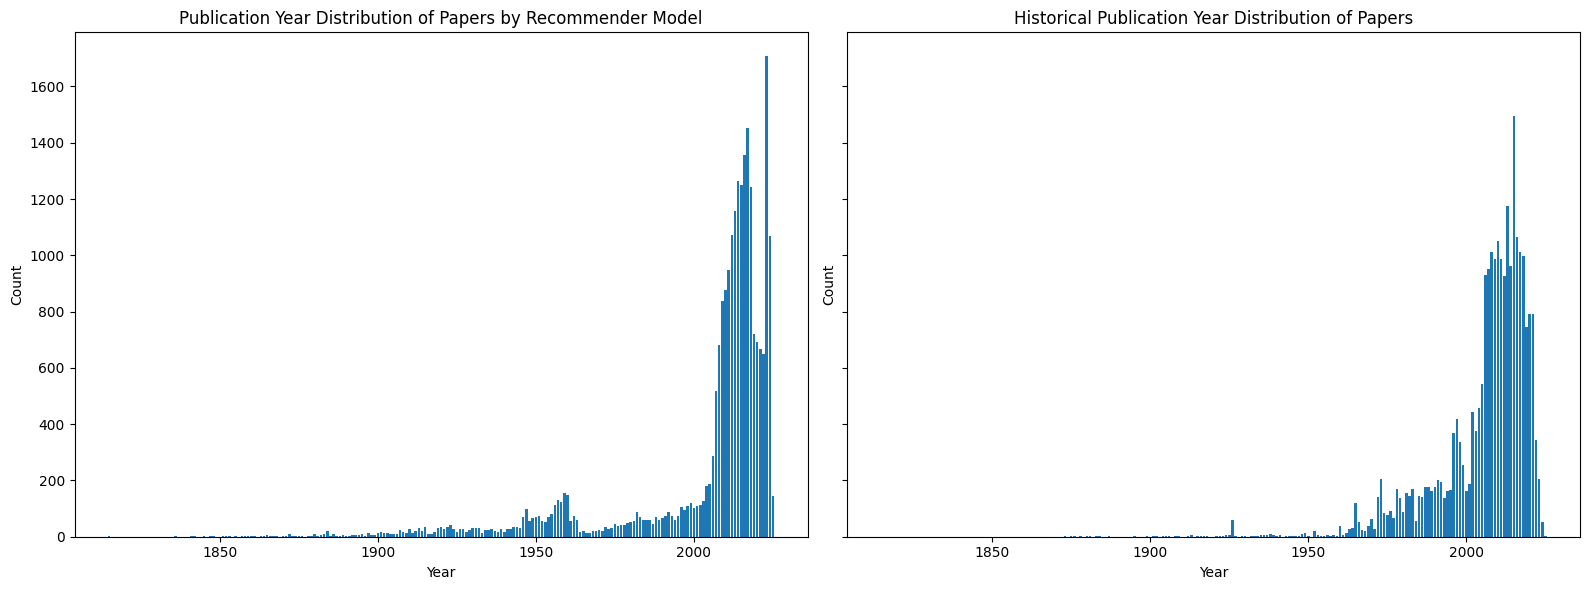

In [244]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

ax1.bar(recommended_papers_df['publication_year'].value_counts().index, recommended_papers_df['publication_year'].value_counts().values)
ax1.set_title("Publication Year Distribution of Papers by Recommender Model")
ax1.set_xlabel("Year")
ax1.set_ylabel("Count")

ax2.bar(sampled_dataset['publication_year'].value_counts().index, sampled_dataset['publication_year'].value_counts().values)
ax2.set_title("Historical Publication Year Distribution of Papers")
ax2.set_xlabel("Year")
ax2.set_ylabel("Count")

plt.tight_layout()

plt.savefig(
    "export_images/DQN Publication Year Distribution",
    dpi=300,               # resolution in dots per inch
    bbox_inches="tight"    # trim extra whitespace
)

plt.show()

### Reputability

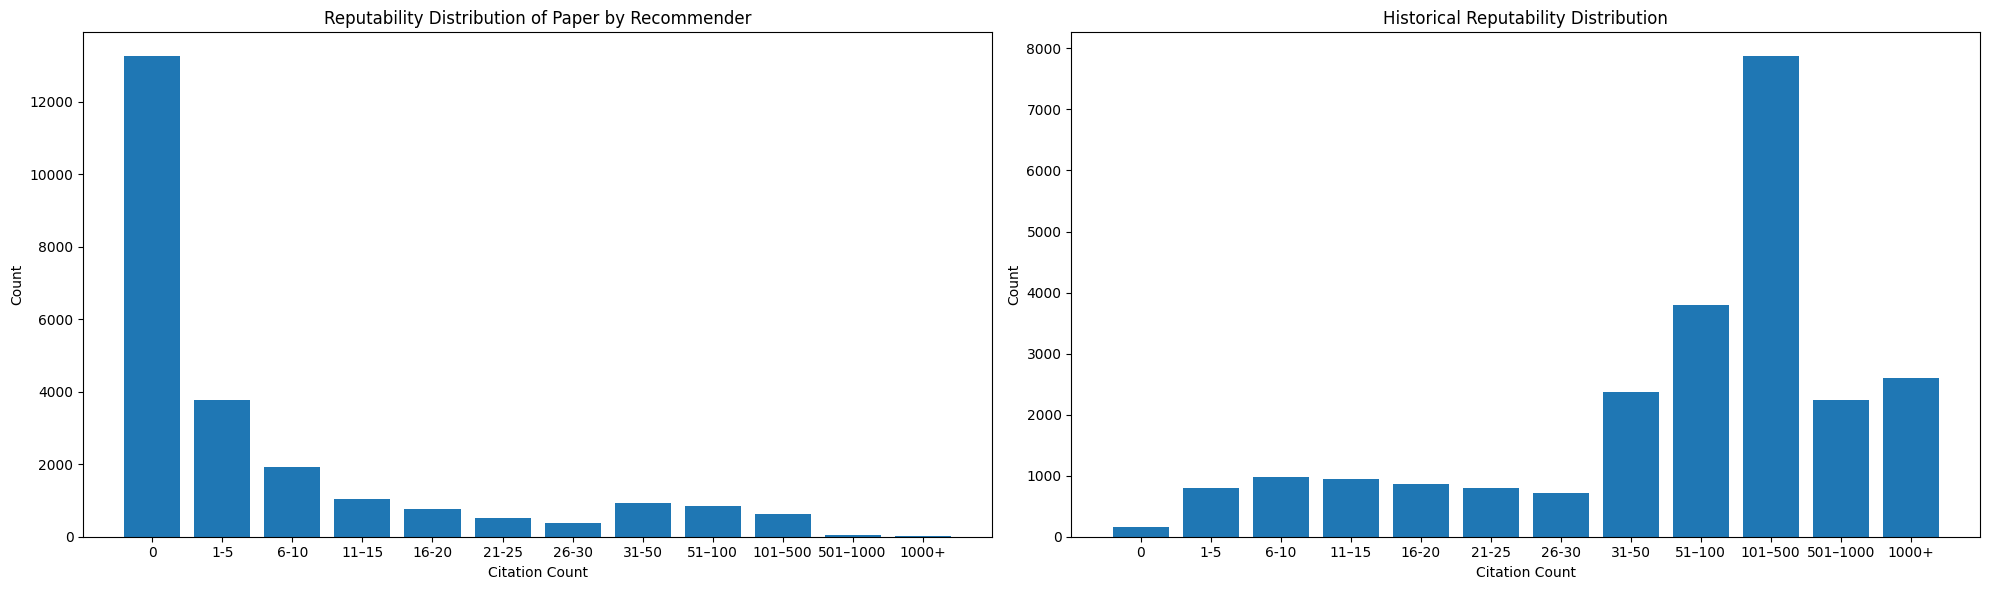

In [245]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

bins = [0, 1, 5, 10, 15, 20, 25, 30, 50, 100, 500, 1000, recommended_papers_df['cited_by_count'].max()]
labels = ['0', '1-5', '6-10', '11–15', '16-20', '21-25', '26-30', '31-50', '51–100', '101–500', '501–1000', '1000+']

cited_by_count = pd.cut(recommended_papers_df['cited_by_count'], bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()

ax1.bar(cited_by_count.index, cited_by_count.values)
ax1.set_title("Reputability Distribution of Paper by Recommender")
ax1.set_xlabel("Citation Count")
ax1.set_ylabel("Count")

dataset_cited_by_count = pd.cut(sampled_dataset['cited_by_count'], bins=bins, labels=labels, include_lowest=True).value_counts().sort_index()

ax2.bar(dataset_cited_by_count.index, dataset_cited_by_count.values)
ax2.set_title("Historical Reputability Distribution")
ax2.set_xlabel("Citation Count")
ax2.set_ylabel("Count")

plt.tight_layout()

plt.savefig(
    "export_images/DQN Reputability Distribution",
    dpi=300,               # resolution in dots per inch
    bbox_inches="tight"    # trim extra whitespace
)

plt.show()

### Overall

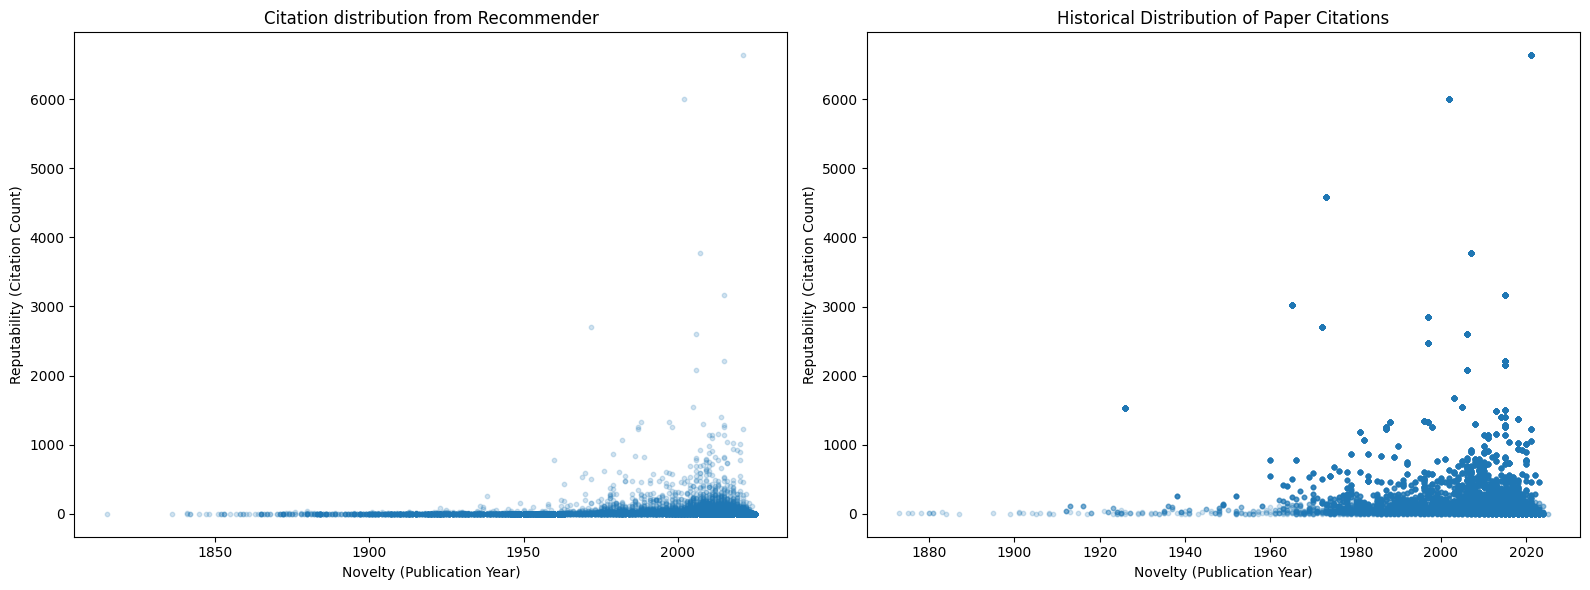

In [247]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(recommended_papers_df['publication_year'], recommended_papers_df['cited_by_count'], alpha=0.2, s=10)
ax1.set_title("Citation distribution from Recommender")
ax1.set_xlabel("Novelty (Publication Year)")
ax1.set_ylabel("Reputability (Citation Count)")

ax2.scatter(sampled_dataset['publication_year'], sampled_dataset['cited_by_count'], alpha=0.2, s=10)
ax2.set_title("Historical Distribution of Paper Citations")
ax2.set_xlabel("Novelty (Publication Year)")
ax2.set_ylabel("Reputability (Citation Count)")

plt.tight_layout()

plt.savefig(
    "export_images/DQN Overall Diversity",
    dpi=300,               # resolution in dots per inch
    bbox_inches="tight"    # trim extra whitespace
)

plt.show()

# Evaluation

In [17]:
import numpy as np


def recommend_k_paper(env, agent, K=10, num_users=5):

    infos = {}
    for user_idx in range(len(env.user_list)):
        print(env.user_list)
        obs, info = env.reset(user_id=user_idx)
        # print(obs)
        done = False

        user_id = info['user_id']

        recommended_items = list()
        while len(recommended_items) < K:
            obs = {k: np.array([v]) for k, v in obs.items()}
            action, _ = agent.predict(obs)
            action = int(action)
            recommended_items.append(action)

            obs, _, done, _, info = env.step(action)
            infos[user_id] = info
            if done:
                obs, info = env.reset(user_id=user_idx)

    return infos

In [24]:
[user.id for user in all_users]

[54, 55, 56, 57, 58, 59, 60, 61, 62]

In [26]:
eval_users_loader = CitationUsersLoader("../environment/users/datasets/users_relevance_threshold.json")
all_users = eval_users_loader.get_users()

env = UserEnv(
        render_mode= "human",
        debug=False,
        debug_path="debug_log/user_env_DQN_eval.log",
        items_loader=paper_loader,
        user_list=all_users,
        items_selector=selector,
        reward_shaping=reward_shaping,
        render_path="./tmp/render/",
        max_interactions=200,
)
env = Monitor(env, filename=f"monitor_DQN_user_eval.csv", info_keywords=("user_id", "item_interact", "item_clicks"))
eval_model = DQN.load("models/random_dqn_citation_recommender", env=env, device="cpu")

recommend_k_paper(env=env, agent=eval_model, K=5, num_users=9)

/var/folders/7y/58r1nbq91psb3zbw1k0f7bzc0000gn/T/ipykernel_5147/3168696164.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  action = int(action)


{0: {'user_id': 0,
  'item_interact': (1364, 1364, 1364, 1364, 1364),
  'item_clicks': (1, 1, 1, 1, 1)},
 1: {'user_id': 1,
  'item_interact': (1364, 1364, 1364, 1364, 1364),
  'item_clicks': (1, 1, 1, 1, 1)},
 2: {'user_id': 2,
  'item_interact': (1364, 1364, 1364, 1364, 1364),
  'item_clicks': (1, 1, 1, 1, 1)},
 3: {'user_id': 3,
  'item_interact': (1364, 1364, 1364, 1364, 22905),
  'item_clicks': (1, 1, 1, 1, 0)},
 4: {'user_id': 4,
  'item_interact': (1364, 1364, 1364, 1364, 1364),
  'item_clicks': (1, 1, 1, 1, 1)},
 5: {'user_id': 5,
  'item_interact': (1364, 1364, 14854, 1364, 1364),
  'item_clicks': (1, 1, 1, 1, 1)},
 6: {'user_id': 6,
  'item_interact': (1364, 1364, 1364, 1364, 1364),
  'item_clicks': (1, 1, 1, 1, 1)},
 7: {'user_id': 7,
  'item_interact': (1364, 1364, 48134, 1364, 32941),
  'item_clicks': (1, 1, 0, 1, 0)},
 8: {'user_id': 8,
  'item_interact': (1364, 1364, 24735, 1364, 1364),
  'item_clicks': (1, 1, 0, 1, 1)}}

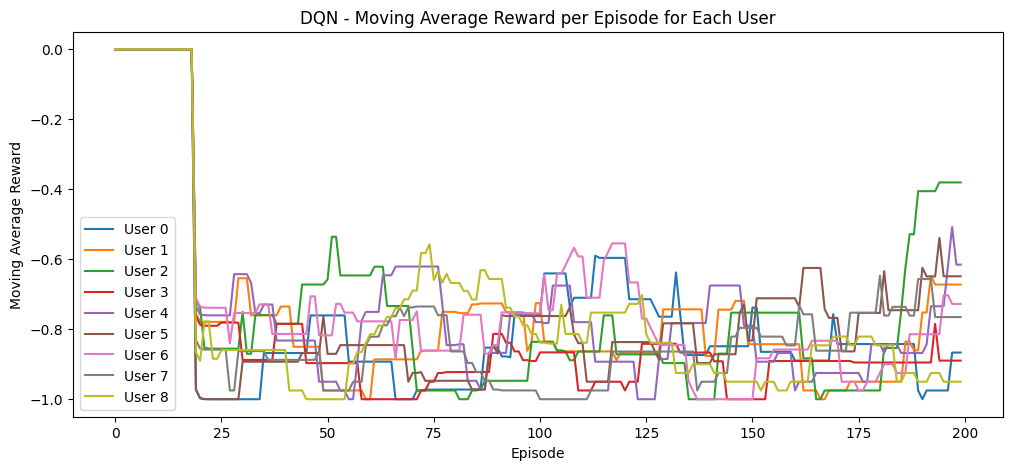

In [26]:
def plot_rewards(all_user_rewards, window_size=20):
    """
    all_user_rewards: list of lists/arrays, each one is the rewards for one user
    window_size: smoothing window for moving average
    """
    plt.figure(figsize=(12, 5))
    plt.xlabel('Episode')
    plt.ylabel('Moving Average Reward')
    plt.title(f"DQN - Moving Average Reward per Episode for Each User")

    for i, rewards in enumerate(all_user_rewards):
        rewards_t = torch.tensor(rewards, dtype=torch.float)

        # raw rewards (optional)
        # plt.plot(rewards_t.numpy(), alpha=0.2, label=f'run {i} raw')

        # smoothed (moving average)
        if len(rewards_t) >= window_size:
            means = rewards_t.unfold(0, window_size, 1).mean(1).view(-1)
            # pad the beginning so lengths match
            pad = torch.zeros(window_size - 1)
            smoothed = torch.cat((pad, means))
            plt.plot(smoothed.numpy(), label=f'User {i}')
        else:
            # too short to smooth, just plot raw
            plt.plot(rewards_t.numpy(), label=f'User {i}')

    plt.legend()

    plt.savefig(
        "export_images/DQN Moving Average Evaluation.png",
        dpi=300,               # resolution in dots per inch
        bbox_inches="tight"    # trim extra whitespace
    )

    plt.show()

plot_rewards([value for key, value in user_rewards.items()])

In [27]:
import pandas as pd
import ast

In [28]:


def to_int_tuple(s: str):
    # 1) replace np.int64(123) with just 123
    cleaned = re.sub(r'np\.int64\(\s*(\d+)\s*\)', r'\1', s)
    # 2) literal_eval the result to get a Python tuple of ints
    return ast.literal_eval(cleaned)

# apply it to your DataFrame
df = pd.read_csv("monitor_DQN_user_eval.csv.monitor.csv", skiprows=1)
df['item_interact_tuple'] = df['item_interact'].apply(ast.literal_eval)
df['item_clicks_tuple'] = df['item_clicks'].apply(ast.literal_eval)

In [38]:
df

,r,l,t,user_id,item_interact,item_clicks,item_interact_tuple,item_clicks_tuple
0,-170.139522,200,1.788300,27,"(28232, 28232, 28232, 28232, 28232, 28232, 282...","(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(28232, 28232, 28232, 28232, 28232, 28232, 282...","(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,-163.467423,200,3.383221,28,"(28232, 28232, 15937, 28232, 28232, 28232, 282...","(0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","(28232, 28232, 15937, 28232, 28232, 28232, 282...","(0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
2,-158.750290,200,5.003350,29,"(28232, 49348, 28232, 28232, 28232, 28232, 282...","(0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","(28232, 49348, 28232, 28232, 28232, 28232, 282...","(0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
3,-177.054492,200,6.608646,30,"(28232, 28232, 28232, 28232, 28232, 34067, 282...","(0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","(28232, 28232, 28232, 28232, 28232, 34067, 282...","(0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ..."
4,-158.830368,200,8.247881,31,"(28232, 28232, 28232, 28232, 28232, 28232, 282...","(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","(28232, 28232, 28232, 28232, 28232, 28232, 282...","(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
5,-165.343521,200,9.825449,32,"(28232, 28232, 28232, 28232, 28232, 28232, 282...","(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(28232, 28232, 28232, 28232, 28232, 28232, 282...","(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,-160.167236,200,11.403360,33,"(28232, 28232, 28232, 28232, 28232, 28232, 282...","(0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","(28232, 28232, 28232, 28232, 28232, 28232, 282...","(0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
7,-171.618597,200,12.982394,34,"(28232, 28232, 28232, 28232, 28232, 28232, 282...","(0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","(28232, 28232, 28232, 28232, 28232, 28232, 282...","(0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
8,-168.884838,200,14.584257,35,"(28232, 28232, 28232, 13426, 28232, 28232, 282...","(0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(28232, 28232, 28232, 13426, 28232, 28232, 282...","(0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [39]:
df[df['user_id'] == 27]['item_interact_tuple']

0    (28232, 28232, 28232, 28232, 28232, 28232, 282...
Name: item_interact_tuple, dtype: object

In [53]:
from collections import Counter

counter = Counter()

for user_id in [user.id for user in all_users]:
    for tup in df[df['user_id'] == user_id]['item_interact_tuple']:
        counter.update(tup)

len(counter.keys())

18

In [43]:
len(counter.keys())

22

In [ ]:
vec_env = model.get_env()
obs = vec_env.reset()
for i in range(1000):
    action, _states = model.predict(obs, deterministic=True)
    obs, rewards, dones, info = vec_env.step(action)
    vec_env.render("human")